In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
#World Constants
g = 9.81


In [ ]:
# Rider Parameters
import csv #standard library, lets us read the rider profiles CSV
from pathlib import Path #builds file paths that work no matter which folder Jupyter was started in

# Pick the rider profile here. Options are the profile_id values in data/rider_profiles.csv:
#   baseline (reproduces the originally submitted rider), male_tt, female_tt, male_climber, female_climber
rider = "baseline"

def load_rider(profile_id):
    """Return one rider profile's parameters from data/rider_profiles.csv as a dict."""
    for base in [Path.cwd(), *Path.cwd().parents]: #start in the current folder and walk up toward the drive root
        if (base / "data" / "rider_profiles.csv").is_file(): #stop once we find the folder holding the profiles file
            data_dir = base / "data"
            break
    else: #the for-loop ran out of folders without finding it
        raise FileNotFoundError("Could not find data/rider_profiles.csv - open this notebook from inside the repo.")

    with open(data_dir / "rider_profiles.csv", newline="") as f: #open the profiles file
        for row in csv.DictReader(f): #DictReader keys each row by the CSV header names
            if row["profile_id"] == profile_id: #match the row to the chosen rider
                return row #hand that rider's parameters back as a dict
    raise ValueError(f"Rider profile '{profile_id}' is not in rider_profiles.csv") #no match - fail loudly

_rider = load_rider(rider) #look up the chosen rider's parameters

m = float(_rider["mass_kg"])                  #Total mass in KG of rider and bike
CdA = float(_rider["cda_m2"])                 # Cd= drag coefficent, A = frontal area
P_max = float(_rider["p_max_w"])              #Short-duration maximal power ceiling
P_threshold = float(_rider["p_threshold_w"])  #Above this power threshold fatigue will build
P_base = float(_rider["p_base_w"])            #Default power output on flat ground

# Shared model constants - same for every rider, so they are not part of the rider profile
P_output = 200 #Power output in watts (const only for now)
Crr = 0.004 #Rolling Resistance coeficcent
v_max = 30 #Cap of rider speed

hill_factor = 800 #How much does rider change power output due to hills

fatigue_rate = 0.05 #how fast fatigue builds when rider is above threshold
recovery_rate = 0.01 #how fast fatigue recovers when below threshold
fatigue_impact = 0.4 #How much fatigue reduces max power

In [ ]:
# Course Segment Inputs
a_density = 1.225 #Air density
hw = 1.0 #Headwind in m/s
grad = 0.03 #Steepness of course in degress from flat (pos = uphill, neg = downhill)
total_distance = 2000.0 #Distance of course in meters

wind_map = {"low" : 0.5, "medium" : 1.0, "high": 2.0} #Wind map dictionary that translate wind exposure from a word to a int

import csv #standard library, lets us read the course CSV files
from pathlib import Path #builds file paths that work no matter which folder Jupyter was started in

course_file = "tokyo_olympic_tt.csv" #the course to run: tokyo_olympic_tt.csv, flanders_world_tt.csv, or custom_5km_loop.csv

def load_course(filename):
    """Return a course from data/courses/ as a list of (name, distance, grade, turn, wind) tuples."""
    for base in [Path.cwd(), *Path.cwd().parents]: #start in the current folder and walk up toward the drive root
        courses_dir = base / "data" / "courses" #the folder the course CSVs live in
        if courses_dir.is_dir(): #once we find it we are inside the repo, so stop looking
            break
    else: #the for-loop ran out of folders without finding it
        raise FileNotFoundError("Could not find data/courses - open this notebook from inside the repo.")

    course = [] #one tuple per segment, same shape as the old hard-coded list
    with open(courses_dir / filename, newline="") as f: #open the chosen course file
        for row in csv.DictReader(f): #DictReader keys each row by the CSV header names
            course.append((
                row["name"], #segment label
                float(row["distance_m"]), #segment length in metres
                float(row["grade_pct"]), #average gradient in percent (+ up / - down)
                float(row["turn_penalty_s"]), #seconds lost braking/cornering on this segment
                row["wind_exposure"], #low / medium / high, turned into m/s later by wind_map
            ))
    return course

course = load_course(course_file) #build the course list the loop reads below

In [5]:
#Trial Assumptions
dt = 1.0 #Timesteps

In [6]:
v = 0.0 #Starting speed = 0
distance = 0.0 #Starting Distance = 0
t = 0 #Starting time = 0
fatigue = 0 #starting fatigue = 0

times = []
speeds = []
distances = []
drags = []
fatigues = []
gradients = []
powers = []

for name, segment_distance, grade_percent, turn_penalty, wind_exposure in course:
    grad = np.arctan(grade_percent / 100) #Since we know the gradient in % this converts it into radians
    hw = wind_map[wind_exposure] #converts wind_exposure to a numerical value usuing the wind_map dictionary
    t += turn_penalty #applies a set extra time cost due to the turn penalty, this is a simplificaiton due to the fact that are race segement 
                            #are so long, so it would not make sense to account for specific corners, rather just a general time penalty
                            #for how curvy the segment is

    segment_start = distance

    
    while distance - segment_start < segment_distance: #accounts for the difference of the segment
        P_target =  max(50, P_base + hill_factor * grad) #this is the target power, will be higher when going up hill, lower downhill
        P_cap = P_max * (1 - fatigue_impact * fatigue) #max power output based on how fatigued the rider is
        P_output = min(P_target, P_cap) #how much the power the rider will output, cannot be greater than P_cap
    
        if P_output > P_threshold: #if the P_output is higher than the riders given power threshold
            fatigue = fatigue + fatigue_rate * (((P_output - P_threshold) / P_threshold)**2 * dt) #squared exceeding term makes fatigue build more if rider
                                                                                    #exceed by large ammounts, /P_threshold so value does not exceed 1
            fatigue = min(fatigue, 1.0) #Makes sure fatigure does not exceed 1.0
        else:
            fatigue = max(0, fatigue - recovery_rate * dt) #fatigue recovery if rider is not in fatigue zone
            
        Rider_force_output = P_output / max(v, 0.50) # power = force * velocity, so force = power/velocity, max is to prevent the divide by 0 
                                                     # since rider starts from rest, 0.5 prevents the function from spiking to a large value
                                                        #when v is very small
        drag = 0.5 * a_density * CdA * ((v + hw)**2) #physics based drag equation
        gravity = m * g * np.sin(grad) #physics gravity equation
        rolling_resistance = Crr * m * g * np.cos(grad)
    
        Rider_Net_force = Rider_force_output - drag - gravity - rolling_resistance
    
        v = max(0, min(v + ((dt/m) * Rider_Net_force), v_max)) #the max prevents v going below 0
                                                                #min prevents v going above v_max
        distance = distance + v *dt
        t = t + dt
    
        times.append(t)
        speeds.append(v)
        distances.append(distance)
        drags.append(drag)
        powers.append(P_output)
        fatigues.append(fatigue)
        gradients.append(grade_percent)

print("Total Time: " + str(round((t/60), 1)) + " min  " + str(round(t%60)) + " seconds") #prints time in minutes and seconds
print("Total Distance: " + str(round((distance/1000), 2)) + " km")
print("Final fatigue: " + str(round(fatigue, 3)))
print("Peak speed: " + str(round(max(speeds)*3.6, 1)) + " km/h")

      
                           

Total Time: 38.7 min  44 seconds
Total Distance: 22.13 km
Final fatigue: 0
Peak speed: 55.3 km/h


[]

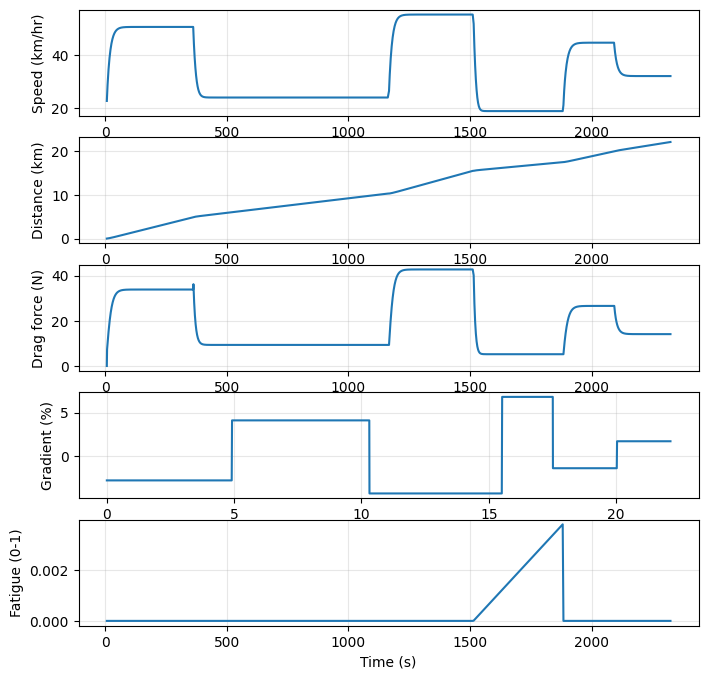

In [7]:
fig, ax = plt.subplots(5,1, figsize=(8,8))

ax[0].plot(times, [s * 3.6 for s in speeds])
ax[0].set_ylabel("Speed (km/hr)")
ax[0].set_xlabel("Time (s)")
ax[0].grid(alpha=0.3)
 
ax[1].plot(times, [d / 1000 for d in distances])
ax[1].set_ylabel("Distance (km)")
ax[1].set_xlabel("Time (s)")
ax[1].grid(alpha=0.3)
 
ax[2].plot(times, drags)
ax[2].set_ylabel("Drag force (N)")
ax[2].set_xlabel("Time (s)")
ax[2].grid(alpha=0.3)

ax[3].plot([d / 1000 for d in distances], gradients)
ax[3].set_ylabel("Gradient (%)")
ax[3].set_xlabel("Distance (km)")
ax[3].grid(alpha=0.3)

ax[4].plot(times, fatigues)
ax[4].set_ylabel("Fatigue (0-1)")
ax[4].set_xlabel("Time (s)")
ax[4].grid(alpha=0.3)

plt.plot()